# Comprehensive Sales Analysis
This notebook analyzes all historical sales files, and provides insights into monthly trends, top items, and categories.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Set plot style
sns.set_theme(style="whitegrid")

# Load the CSV files and combine them
csv_files = glob.glob('data/*sales.csv')
dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

# Convert Date and Time to datetime objects
df['Date and Time'] = pd.to_datetime(df['Date and Time'])
# Add a Year-Month column for easier grouping
df['Month'] = df['Date and Time'].dt.to_period('M').astype(str)

C:\Users\evang\AppData\Local\Temp\ipykernel_5240\1738262804.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Month'] = df['Date and Time'].dt.to_period('M').astype(str)


## 1. Overall Sales Summaries

In [2]:
# Calculate the total sum of Revenue
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

# Calculate the total sum of Price
total_price = df['Price'].sum()
print(f"Total Price: ${total_price:,.2f}")

# Find the overall most bought item
most_bought_item = df['Asset Name'].value_counts().idxmax()
most_bought_count = df['Asset Name'].value_counts().max()

print(f"\nMost bought item overall: '{most_bought_item}' with {most_bought_count} purchases.")

Total Revenue: $304,130.00
Total Price: $382,859.00

Most bought item overall: 'Bear' with 75460 purchases.


## 2. Monthly Revenue Trends

C:\Users\evang\AppData\Local\Temp\ipykernel_5240\709827235.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')


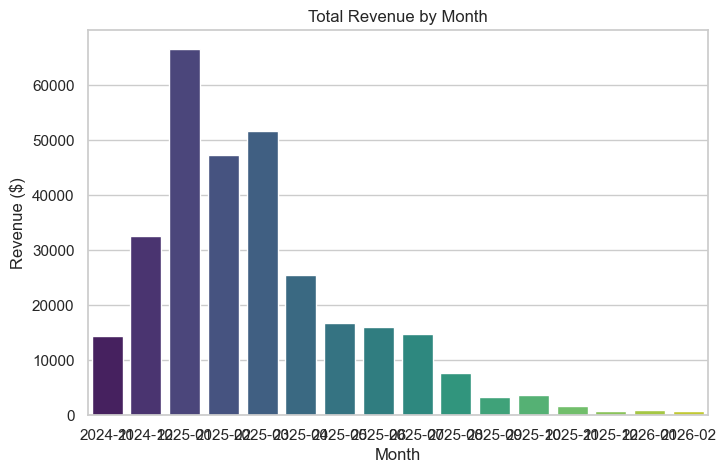

In [3]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.show()

## 3. Top 10 Most Bought Items

C:\Users\evang\AppData\Local\Temp\ipykernel_5240\4276871170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_items.values, y=top_10_items.index, palette='mako')
C:\Users\evang\anaconda3\envs\tensorflow_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


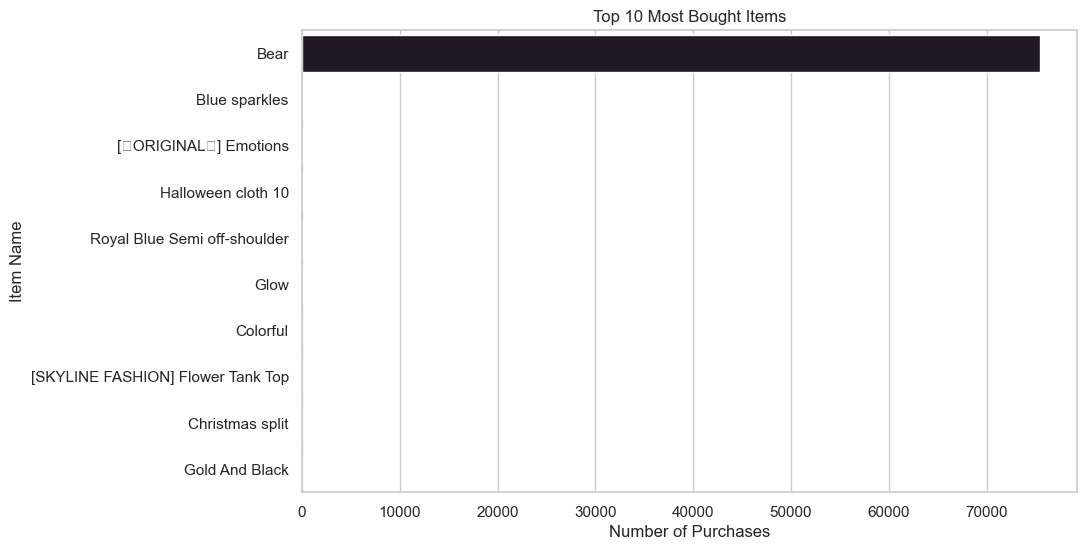

In [4]:
top_10_items = df['Asset Name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_items.values, y=top_10_items.index, palette='mako')
plt.title('Top 10 Most Bought Items')
plt.xlabel('Number of Purchases')
plt.ylabel('Item Name')
plt.show()

## 4. Category Analysis (Asset Type)

C:\Users\evang\AppData\Local\Temp\ipykernel_5240\4131283439.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='rocket')


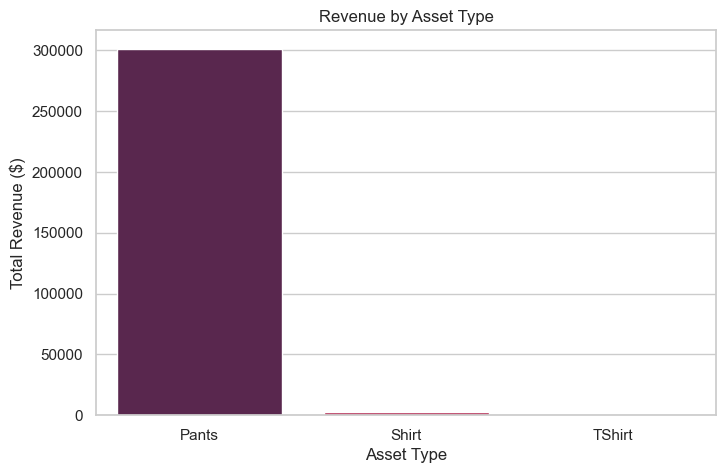

In [5]:
category_revenue = df.groupby('Asset Type')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='rocket')
plt.title('Revenue by Asset Type')
plt.xlabel('Asset Type')
plt.ylabel('Total Revenue ($)')
plt.show()

## 5. Top Environments and Spenders

In [6]:
# Sales grouped by Location (e.g., Website vs Game)
location_sales = df['Location'].value_counts().reset_index()
location_sales.columns = ['Location', 'Purchases']

print("Purchases by Location:")
print(location_sales.to_string(index=False))
print("\n" + "-"*30 + "\n")

# Top 5 Buyers by total amount spent
top_spenders = df.groupby('Buyer User Id')['Revenue'].sum().sort_values(ascending=False).head(5).reset_index()
print("Top 5 Spenders:")
print(top_spenders.to_string(index=False))

Purchases by Location:
Location  Purchases
 Website      74489
    Game       2032

------------------------------

Top 5 Spenders:
 Buyer User Id  Revenue
    8251657839     24.0
    1063177953     16.0
     340480599     12.0
    2442144441     12.0
    7620400413     12.0
